
# Classical MLP PINN baseline for the 1D heat equation

This notebook is a self-contained classical baseline for the hackathon challenge on photonic Quantum PINNs.

It solves the same benchmark problem as the MerLin QPINN starter notebook, but replaces the quantum layer with a standard multilayer perceptron (MLP). Participants should use this notebook as a fair classical reference when evaluating whether the quantum layer is useful.

The target PDE is the 1D heat equation:

$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2},
\qquad x \in [0,1], \quad t \in [0,1].
$$

We use the analytical solution

$$
u(x,t) = e^{-\alpha \pi^2 t}\sin(\pi x),
$$

which corresponds to

$$
u(x,0)=\sin(\pi x), \qquad u(0,t)=u(1,t)=0.
$$

The notebook implements a Physics-Informed Neural Network (PINN) with losses for the PDE residual, initial condition, and boundary conditions. It also includes an optional auxiliary derivative formulation, similar to the structure used in the QPINN paper and the MerLin notebook.



## Installation

The notebook only requires PyTorch, NumPy and Matplotlib.

```bash
pip install torch numpy matplotlib
```

If you run this on a GPU, PyTorch will use it automatically if available.


In [ ]:

import math
import time
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32

print("Device:", DEVICE)
print("Torch version:", torch.__version__)


Device: cpu
Torch version: 2.10.0+cu128



## Problem definition

We solve

$$
u_t - \alpha u_{xx}=0.
$$

The exact solution is used only for evaluation and for the initial condition. It is not used inside the PDE residual.


In [ ]:

alpha = 0.1


def exact_u(x, t):
    """Exact solution of the benchmark heat equation."""
    return torch.exp(-alpha * math.pi**2 * t) * torch.sin(math.pi * x)


def make_xt(x, t):
    """Concatenate x and t into a two-column input tensor."""
    return torch.cat([x, t], dim=1)



## Sampling collocation, initial and boundary points

The PINN is trained without a labeled dataset in the interior. Instead, it samples collocation points and minimizes the PDE residual there.


In [ ]:

def sample_interior(n):
    x = torch.rand(n, 1, device=DEVICE, dtype=DTYPE)
    t = torch.rand(n, 1, device=DEVICE, dtype=DTYPE)
    xt = make_xt(x, t)
    xt.requires_grad_(True)
    return xt


def sample_initial(n):
    x = torch.rand(n, 1, device=DEVICE, dtype=DTYPE)
    t = torch.zeros_like(x)
    xt = make_xt(x, t)
    y = exact_u(x, t)
    return xt, y


def sample_boundary(n):
    n0 = n // 2
    n1 = n - n0
    t0 = torch.rand(n0, 1, device=DEVICE, dtype=DTYPE)
    t1 = torch.rand(n1, 1, device=DEVICE, dtype=DTYPE)
    x0 = torch.zeros_like(t0)
    x1 = torch.ones_like(t1)
    xt = torch.cat([make_xt(x0, t0), make_xt(x1, t1)], dim=0)
    y = torch.zeros(n, 1, device=DEVICE, dtype=DTYPE)
    return xt, y



## Classical MLP architecture

This is the main classical baseline. The model maps $(x,t)$ to $u_\theta(x,t)$.

The hidden width and depth can be changed to match the parameter count of a hybrid quantum-classical model.


In [ ]:

class MLP_PINN(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=32, depth=4, out_dim=1, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), activation()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), activation()]
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, xt):
        return self.net(xt)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model = MLP_PINN(hidden_dim=32, depth=4).to(device=DEVICE, dtype=DTYPE)
print(model)
print("Trainable parameters:", count_parameters(model))


MLP_PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): Tanh()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable parameters: 3297



## PDE residual with direct second derivatives

This is the standard PINN formulation. We compute

$$
r(x,t) = u_t - \alpha u_{xx}.
$$

The loss drives this residual toward zero.


In [ ]:

def pde_residual_direct(model, xt):
    """Compute u_t - alpha * u_xx using PyTorch automatic differentiation."""
    u = model(xt)

    grads = torch.autograd.grad(
        outputs=u,
        inputs=xt,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
    )[0]

    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]

    grads2 = torch.autograd.grad(
        outputs=u_x,
        inputs=xt,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True,
    )[0]

    u_xx = grads2[:, 0:1]
    return u_t - alpha * u_xx



## Optional auxiliary-derivative MLP

The paper-style trick is to output both $u_\theta$ and an auxiliary derivative $\hat u_x$. The PDE residual becomes

$$
r(x,t)=u_t - \alpha \partial_x \hat u_x,
$$

and a consistency loss enforces

$$
u_x \approx \hat u_x.
$$

This avoids differentiating $u$ twice directly, although it introduces a second learned quantity and an additional loss term. This notebook supports both modes so hackers can ablate the trick.


In [ ]:

class MLP_AuxPINN(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=32, depth=4, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), activation()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), activation()]
        layers.append(nn.Linear(hidden_dim, 2))  # output: [u, u_x_hat]
        self.net = nn.Sequential(*layers)

    def forward(self, xt):
        y = self.net(xt)
        u = y[:, 0:1]
        ux_hat = y[:, 1:2]
        return u, ux_hat


def pde_residual_aux(model, xt):
    """Compute u_t - alpha * d/dx(ux_hat), plus consistency u_x - ux_hat."""
    u, ux_hat = model(xt)

    grad_u = torch.autograd.grad(
        outputs=u,
        inputs=xt,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
    )[0]
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]

    grad_ux_hat = torch.autograd.grad(
        outputs=ux_hat,
        inputs=xt,
        grad_outputs=torch.ones_like(ux_hat),
        create_graph=True,
        retain_graph=True,
    )[0]
    ux_hat_x = grad_ux_hat[:, 0:1]

    residual = u_t - alpha * ux_hat_x
    consistency = u_x - ux_hat
    return residual, consistency



## Training configuration

Set `USE_AUXILIARY_DERIVATIVE = False` for the standard direct-derivative PINN.

Set it to `True` to train the auxiliary-derivative version, which is closer to the QPINN paper structure.


In [ ]:

@dataclass
class TrainConfig:
    epochs: int = 300
    n_f: int = 256
    n_i: int = 128
    n_b: int = 128
    lr: float = 1e-3
    lambda_pde: float = 1.0
    lambda_ic: float = 10.0
    lambda_bc: float = 10.0
    lambda_consistency: float = 1.0
    print_every: int = 300


USE_AUXILIARY_DERIVATIVE = False
config = TrainConfig()

if USE_AUXILIARY_DERIVATIVE:
    model = MLP_AuxPINN(hidden_dim=32, depth=4).to(device=DEVICE, dtype=DTYPE)
else:
    model = MLP_PINN(hidden_dim=32, depth=4).to(device=DEVICE, dtype=DTYPE)

optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)
mse = nn.MSELoss()

print("Using auxiliary derivative:", USE_AUXILIARY_DERIVATIVE)
print("Trainable parameters:", count_parameters(model))


Using auxiliary derivative: False
Trainable parameters: 3297


In [ ]:

history = {"total": [], "pde": [], "ic": [], "bc": [], "consistency": []}
start = time.time()

for epoch in range(1, config.epochs + 1):
    optimizer.zero_grad()

    xt_f = sample_interior(config.n_f)
    xt_i, y_i = sample_initial(config.n_i)
    xt_b, y_b = sample_boundary(config.n_b)

    if USE_AUXILIARY_DERIVATIVE:
        res, consistency = pde_residual_aux(model, xt_f)
        u_i, _ = model(xt_i)
        u_b, _ = model(xt_b)
        loss_consistency = mse(consistency, torch.zeros_like(consistency))
    else:
        res = pde_residual_direct(model, xt_f)
        u_i = model(xt_i)
        u_b = model(xt_b)
        loss_consistency = torch.tensor(0.0, device=DEVICE, dtype=DTYPE)

    loss_pde = mse(res, torch.zeros_like(res))
    loss_ic = mse(u_i, y_i)
    loss_bc = mse(u_b, y_b)

    loss = (
        config.lambda_pde * loss_pde
        + config.lambda_ic * loss_ic
        + config.lambda_bc * loss_bc
        + config.lambda_consistency * loss_consistency
    )

    loss.backward()
    optimizer.step()

    history["total"].append(loss.item())
    history["pde"].append(loss_pde.item())
    history["ic"].append(loss_ic.item())
    history["bc"].append(loss_bc.item())
    history["consistency"].append(loss_consistency.item())

    if epoch % config.print_every == 0 or epoch == 1:
        print(
            f"Epoch {epoch:5d} | loss={loss.item():.3e} | "
            f"pde={loss_pde.item():.3e} | ic={loss_ic.item():.3e} | "
            f"bc={loss_bc.item():.3e} | cons={loss_consistency.item():.3e}"
        )

elapsed = time.time() - start
print(f"Training time: {elapsed:.1f} s")


Epoch     1 | loss=4.996e+00 | pde=2.973e-06 | ic=4.987e-01 | bc=9.356e-04 | cons=0.000e+00
Epoch   300 | loss=9.450e-03 | pde=7.028e-03 | ic=1.025e-04 | bc=1.397e-04 | cons=0.000e+00
Training time: 16.8 s



## Training curves


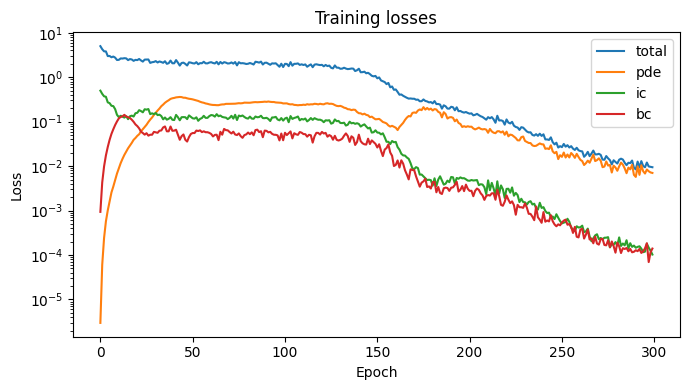

In [ ]:

plt.figure(figsize=(7, 4))
for key, values in history.items():
    if key == "consistency" and not USE_AUXILIARY_DERIVATIVE:
        continue
    plt.semilogy(values, label=key)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training losses")
plt.tight_layout()
plt.show()



## Evaluation on a grid

The relative $L^2$ error is

$$
\frac{\|u_\theta-u_{\mathrm{true}}\|_2}{\|u_{\mathrm{true}}\|_2}.
$$


In [ ]:

@torch.no_grad()
def predict_u(model, xt):
    if USE_AUXILIARY_DERIVATIVE:
        u, _ = model(xt)
        return u
    return model(xt)


def evaluate_on_grid(model, nx=101, nt=101):
    x = torch.linspace(0, 1, nx, device=DEVICE, dtype=DTYPE).view(-1, 1)
    t = torch.linspace(0, 1, nt, device=DEVICE, dtype=DTYPE).view(-1, 1)
    X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
    xt = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

    u_pred = predict_u(model, xt).reshape(nx, nt)
    u_true = exact_u(X, T)

    rel_l2 = torch.linalg.norm(u_pred - u_true) / torch.linalg.norm(u_true)
    max_abs = torch.max(torch.abs(u_pred - u_true))
    return X.detach().cpu(), T.detach().cpu(), u_pred.detach().cpu(), u_true.detach().cpu(), rel_l2.item(), max_abs.item()


X, T, U_pred, U_true, rel_l2, max_abs = evaluate_on_grid(model)
print(f"Relative L2 error: {rel_l2:.4e}")
print(f"Max absolute error: {max_abs:.4e}")


Relative L2 error: 1.5626e-02
Max absolute error: 4.0074e-02


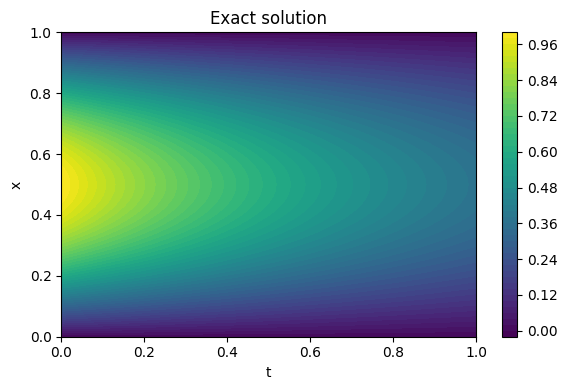

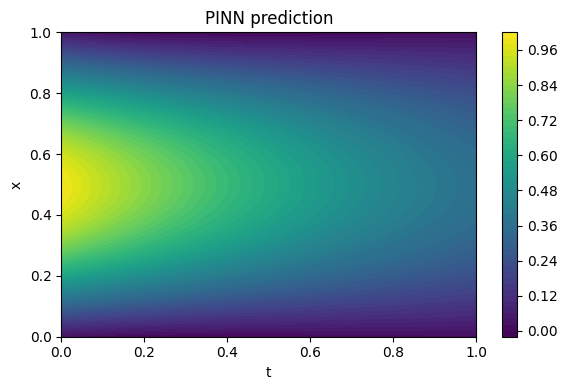

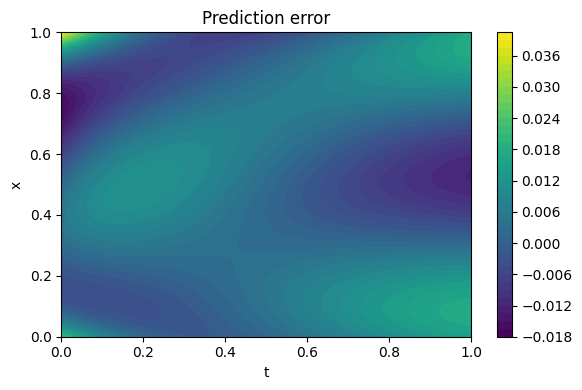

In [ ]:

plt.figure(figsize=(6, 4))
plt.contourf(T.numpy(), X.numpy(), U_true.numpy(), levels=50)
plt.xlabel("t")
plt.ylabel("x")
plt.title("Exact solution")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.contourf(T.numpy(), X.numpy(), U_pred.numpy(), levels=50)
plt.xlabel("t")
plt.ylabel("x")
plt.title("PINN prediction")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.contourf(T.numpy(), X.numpy(), (U_pred - U_true).numpy(), levels=50)
plt.xlabel("t")
plt.ylabel("x")
plt.title("Prediction error")
plt.colorbar()
plt.tight_layout()
plt.show()



## Suggested ablation use

This notebook should be used as a baseline against the MerLin QPINN model.

For a fair comparison, try to match the number of trainable parameters, number of collocation points, optimizer and learning rate, number of epochs or wall-clock training budget, random seeds, and evaluation grid.

Useful variants to compare include the direct-derivative MLP PINN, the auxiliary-derivative MLP PINN, the MerLin QPINN with a trainable quantum layer, the MerLin QPINN with a frozen quantum layer, the MerLin QPINN with the quantum layer replaced by a classical linear layer, and a same-parameter MLP baseline.

A strong conclusion requires several random seeds. Report mean and standard deviation for relative $L^2$ error, PDE residual, training time, and parameter count.



## Optional extension: Poisson equation

For the Poisson part of the challenge, the same structure can be reused for an equation such as

$$
u_{xx}(x)=f(x), \qquad x\in[0,1],
$$

with exact solution

$$
u(x)=\sin(\pi x), \qquad f(x)=-\pi^2\sin(\pi x),
$$

and boundary conditions $u(0)=u(1)=0$.

Participants can add a second model or second training loop by replacing the heat residual with

$$
r(x)=u_{xx}(x)-f(x).
$$



### Poisson equation implementation

This adds a minimal Poisson PINN using the same MLP class, with inputs x only.
Run the next two cells to train and evaluate.

In [ ]:

def poisson_exact_u(x):
    """Exact solution for the Poisson benchmark."""
    return torch.sin(math.pi * x)


def poisson_f(x):
    """Right-hand side f(x) for u_xx = f(x)."""
    return -math.pi**2 * torch.sin(math.pi * x)


def sample_poisson_interior(n):
    x = torch.rand(n, 1, device=DEVICE, dtype=DTYPE)
    x.requires_grad_(True)
    return x


def sample_poisson_boundary(n):
    n0 = n // 2
    n1 = n - n0
    x0 = torch.zeros(n0, 1, device=DEVICE, dtype=DTYPE)
    x1 = torch.ones(n1, 1, device=DEVICE, dtype=DTYPE)
    x = torch.cat([x0, x1], dim=0)
    y = torch.zeros(n, 1, device=DEVICE, dtype=DTYPE)
    return x, y


def pde_residual_poisson(model, x):
    """Compute u_xx - f(x) using automatic differentiation."""
    u = model(x)
    grad_u = torch.autograd.grad(
        outputs=u,
        inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
    )[0]
    u_x = grad_u[:, 0:1]
    grad2 = torch.autograd.grad(
        outputs=u_x,
        inputs=x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True,
    )[0]
    u_xx = grad2[:, 0:1]
    return u_xx - poisson_f(x)


@dataclass
class PoissonConfig:
    epochs: int = 500
    n_f: int = 256
    n_b: int = 128
    lr: float = 1e-3
    lambda_pde: float = 1.0
    lambda_bc: float = 10.0
    print_every: int = 200


poisson_config = PoissonConfig()
poisson_model = MLP_PINN(in_dim=1, hidden_dim=32, depth=4).to(device=DEVICE, dtype=DTYPE)
poisson_optimizer = torch.optim.Adam(poisson_model.parameters(), lr=poisson_config.lr)
poisson_history = {"total": [], "pde": [], "bc": []}


start = time.time()
for epoch in range(1, poisson_config.epochs + 1):
    poisson_optimizer.zero_grad()

    x_f = sample_poisson_interior(poisson_config.n_f)
    x_b, y_b = sample_poisson_boundary(poisson_config.n_b)

    res = pde_residual_poisson(poisson_model, x_f)
    u_b = poisson_model(x_b)

    loss_pde = mse(res, torch.zeros_like(res))
    loss_bc = mse(u_b, y_b)
    loss = poisson_config.lambda_pde * loss_pde + poisson_config.lambda_bc * loss_bc

    loss.backward()
    poisson_optimizer.step()

    poisson_history["total"].append(loss.item())
    poisson_history["pde"].append(loss_pde.item())
    poisson_history["bc"].append(loss_bc.item())

    if epoch % poisson_config.print_every == 0 or epoch == 1:
        print(
            f"Epoch {epoch:5d} | loss={loss.item():.3e} | "
            f"pde={loss_pde.item():.3e} | bc={loss_bc.item():.3e}"
        )


elapsed = time.time() - start
print(f"Poisson training time: {elapsed:.1f} s")


In [ ]:

@torch.no_grad()
def evaluate_poisson(model, nx=201):
    x = torch.linspace(0, 1, nx, device=DEVICE, dtype=DTYPE).view(-1, 1)
    u_pred = model(x)
    u_true = poisson_exact_u(x)
    rel_l2 = torch.linalg.norm(u_pred - u_true) / torch.linalg.norm(u_true)
    max_abs = torch.max(torch.abs(u_pred - u_true))
    return x.detach().cpu(), u_pred.detach().cpu(), u_true.detach().cpu(), rel_l2.item(), max_abs.item()


x_p, u_p, u_t, rel_l2_p, max_abs_p = evaluate_poisson(poisson_model)
print(f"Poisson relative L2 error: {rel_l2_p:.4e}")
print(f"Poisson max absolute error: {max_abs_p:.4e}")


plt.figure(figsize=(6, 4))
plt.plot(x_p.numpy(), u_t.numpy(), label="Exact")
plt.plot(x_p.numpy(), u_p.numpy(), "--", label="PINN")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Poisson solution")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
plt.semilogy(poisson_history["total"], label="total")
plt.semilogy(poisson_history["pde"], label="pde")
plt.semilogy(poisson_history["bc"], label="bc")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Poisson training losses")
plt.legend()
plt.tight_layout()
plt.show()
